<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/Assetclass_correlations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HYPOTHESES:

The Credit Quality Divergence:

During expansions, High Yield (HYG) behaves like a blend of fixed income and equity.

During recessions, notice how its correlation with SPY spikes higher, while **High-Quality Treasuries** (TLT) drop into deep **negative correlation with equities**. This is the classic "flight to quality" institutional shift.

The Commodity Split:

Institutional desks treat commodities as individual risk factors rather than a single bucket. Look at Gold (GLD) vs Copper (CPER) during recessions.

**Copper (the ultimate economic bellwether) usually crashes alongside equities, while Gold's correlation decoupled or inverted as a safe haven.**

Real Estate Breakdown:

See how VNQ (**Real Estate**) responds. In normal times, it offers decent diversification, but **during systemic recessions (like 2008), its correlation to equities tightens drastically due to shared liquidity/credit constraints.**

In [1]:
!pip install yfinance pandas-datareader seaborn matplotlib

[**********************56%**                     ]  5 of 9 completed

Fetching asset price data from Yahoo Finance...


[*********************100%***********************]  9 of 9 completed


Fetching NBER Macro Regime data from FRED...


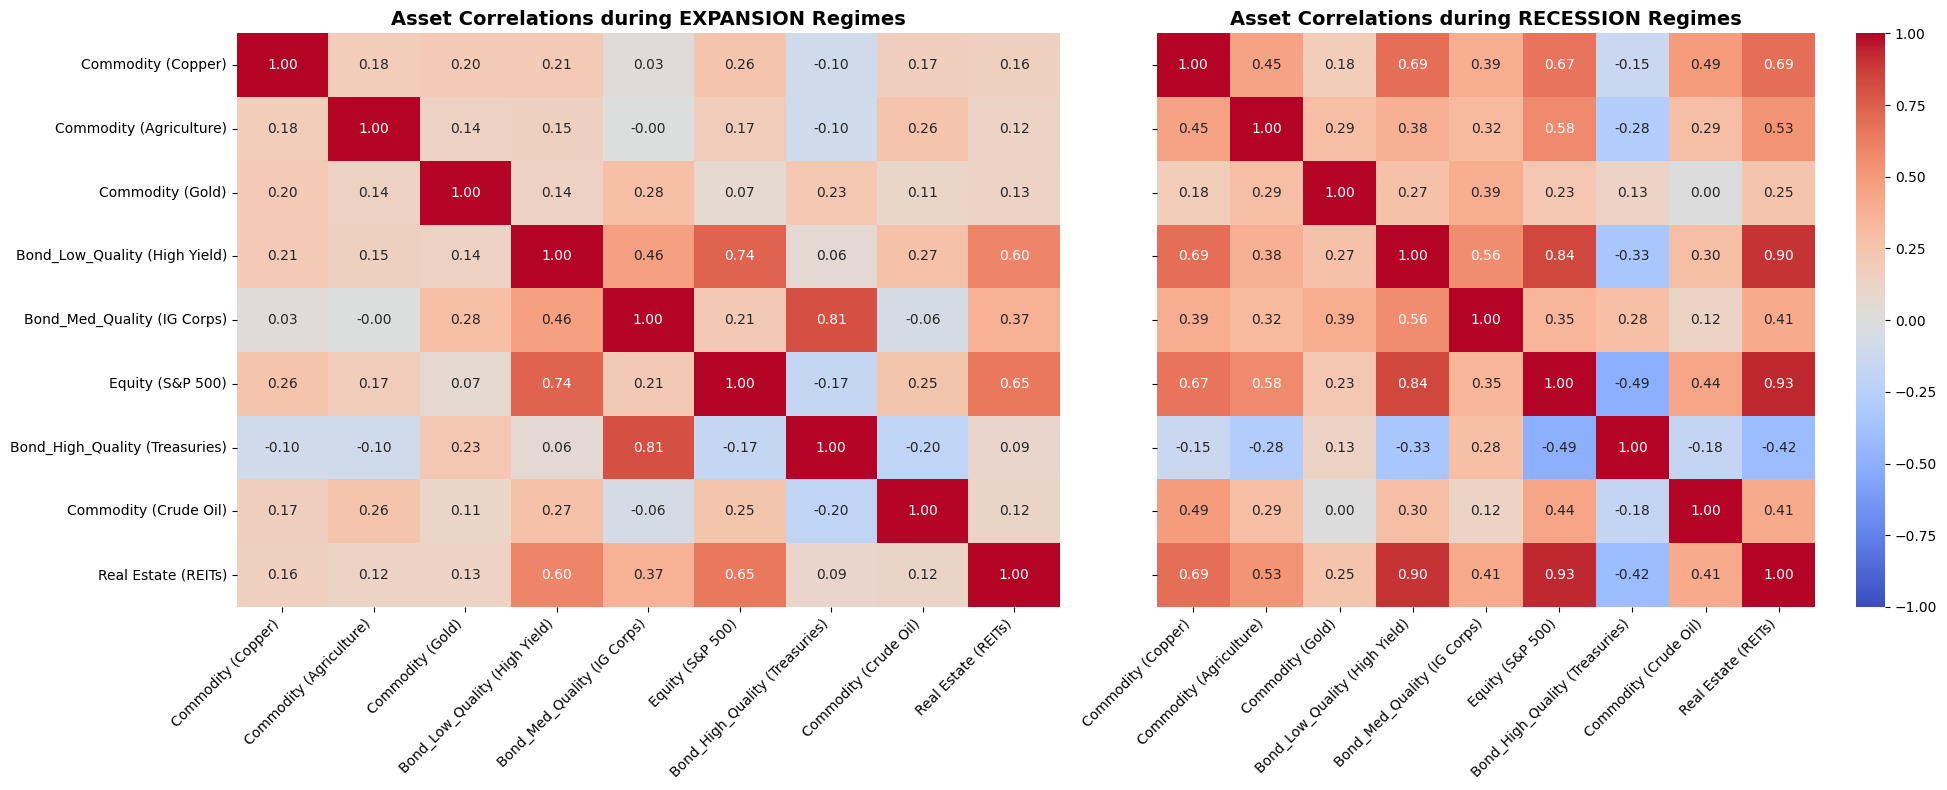

In [3]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader.data as web
import seaborn as sns
import yfinance as yf

# 1. Define Timeframe and Tickers
start_date = "2008-01-01"  # Captures 2008 GFC, 2020 Covid, and 2022 inflation shocks
end_date = datetime.datetime.now().strftime("%Y-%m-%d")

ticker_dict = {
    # Equities & Real Estate
    "SPY": "Equity (S&P 500)",
    "VNQ": "Real Estate (REITs)",
    # Fixed Income by Credit Quality
    "TLT": "Bond_High_Quality (Treasuries)",
    "LQD": "Bond_Med_Quality (IG Corps)",
    "HYG": "Bond_Low_Quality (High Yield)",
    # Top Commodities
    "GLD": "Commodity (Gold)",
    "USO": "Commodity (Crude Oil)",
    "CPER": "Commodity (Copper)",
    "DBA": "Commodity (Agriculture)",
}

# 2. Download Asset Data & Calculate Daily Returns
print("Fetching asset price data from Yahoo Finance...")
data = yf.download(list(ticker_dict.keys()), start=start_date, end=end_date, auto_adjust=False)[
    "Adj Close"
]
data = data.rename(columns=ticker_dict)
returns = data.pct_change().dropna()

# 3. Fetch NBER Recession Data from FRED
print("Fetching NBER Macro Regime data from FRED...")
recession_indicator = web.DataReader("USRECDM", "fred", start_date, end_date)

# Align the daily returns with the monthly/daily recession flag
# FRED provides daily flags where 1 = Recession, 0 = Expansion
returns_regime = returns.join(recession_indicator, how="inner")

# 4. Separate Data by Economic Regime
expansion_returns = returns_regime[returns_regime["USRECDM"] == 0].drop(
    columns=["USRECDM"]
)
recession_returns = returns_regime[returns_regime["USRECDM"] == 1].drop(
    columns=["USRECDM"]
)

# 5. Calculate Correlation Matrices
corr_expansion = expansion_returns.corr()
corr_recession = recession_returns.corr()

# 6. Plotting the Institutional Dashboard
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Plot Expansion Matrix
sns.heatmap(
    corr_expansion,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    ax=axes[0],
    cbar=False,
)
axes[0].set_title(
    "Asset Correlations during EXPANSION Regimes", fontsize=14, fontweight="bold"
)
axes[0].set_xticklabels(
    axes[0].get_xticklabels(), rotation=45, horizontalalignment="right"
)

# Plot Recession Matrix
sns.heatmap(
    corr_recession,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    ax=axes[1],
    cbar=True,
)
axes[1].set_title(
    "Asset Correlations during RECESSION Regimes", fontsize=14, fontweight="bold"
)
axes[1].set_xticklabels(
    axes[1].get_xticklabels(), rotation=45, horizontalalignment="right"
)

plt.tight_layout()
plt.show()

AFTERTHOUGHTS / CONCLUSIONS:


We clearly see **correlation instability across economic regimes**.

These heatmaps expose why standard "static" diversification models fail right when investors need them most.

1. The Death of Diversification (Correlation Convergence)
There is a cluster between Equity (S&P 500), Real Estate (REITs), and Bond_Low_Quality (High Yield):

In Expansion: Equity and REITs have a healthy correlation of 0.65. Equity and High Yield sit at 0.74. There is still room for structural alpha and asset-class differentiation.

In Recession: The correlation between Equity and REITs sky-rockets to 0.93, and High Yield to Equity hits 0.84.

Takeaway: **During a crisis, all risk assets converge toward a correlation of 1**. This happens because institutional players face margin calls and liquidity constraints, forcing them to sell what they can rather than what they want, leading to indiscriminate selling across Equities, Real Estate, and High-Yield credit.


2. High-Yield Bonds are "Equities in Disguise"
Fixed-income mandates often group High-Yield (HYG) into the bond bucket, but look at its behavior during recessions:
Its correlation with the S&P 500 is 0.84.
Its correlation with Real Estate is 0.90.
Meanwhile, its correlation with High-Quality Treasuries goes deeply negative (-0.33).

Takeaway: Multi-asset desks treat **High-Yield debt as equity-risk risk factors, not fixed-income**. If a portfolio manager thinks they are "de-risking" by moving from equities into high-yield corporate bonds during a recessionary turn, this data proves they are just swapping one equity-like beta for another.


3. The Ultimate Hedge: High-Quality Treasuries
Notice the behavior of Bond_High_Quality (Treasuries):

In expansions, Treasuries have a mildly negative correlation with equities (-0.17).
In recessions, that relationship deepens dramatically to -0.49.

Institutional Takeaway: This is the textbook **"flight-to-safety." When growth assets collapse, capital floods into risk-free government debt, driving yields down and bond prices up**. This negative correlation is the primary engine behind the classic 60/40 portfolio's defensive capabilities during a growth shock.


4. Commodity De-coupling ("Dr. Copper" vs. Gold)
Institutions never view "commodities" as a single monolithic asset class because their underlying drivers are completely different:

**Copper**: Its correlation to equities spikes from 0.26 (Expansion) to 0.67 (Recession). This reflects its status as an **industrial cyclical asset; when global production stalls, Copper drops lockstep with the stock market.**

**Gold**: It maintains a remarkably insulated profile, shifting only slightly from 0.07 to 0.23.

Institutional Takeaway: Gold remains a unique **macro-rebel. While industrial commodities contract alongside corporate earnings due to falling demand, gold maintains its low-correlation profile because it responds to real yields and fiat debasement fears rather than industrial output.**